In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, precision_recall_curve, classification_report
)

# --- Данные ---
X_train_full = pd.read_csv('../data/processed/X_train.csv')
X_test       = pd.read_csv('../data/processed/X_test.csv')
y_train_full = pd.read_csv('../data/processed/y_train.csv')['Class'].astype(int).values
y_test       = pd.read_csv('../data/processed/y_test.csv')['Class'].astype(int).values


X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20, stratify=y_train_full, random_state=42
)

print(f"Train: {X_tr.shape}, фрод: {y_tr.sum()}")
print(f"Val:   {X_val.shape}, фрод: {y_val.sum()}")
print(f"Test:  {X_test.shape}, фрод: {y_test.sum()}")

AVG_FRAUD_AMOUNT = 122.0
COST_FP = 5.0

Train: (181584, 30), фрод: 302
Val:   (45396, 30), фрод: 76
Test:  (56746, 30), фрод: 95


## Загрузка лучшей модели LightGBM

In [4]:
lgbm_base = joblib.load('../models/best_tree_model.pkl')
print("Загружена модель:", type(lgbm_base).__name__)

# Probas на val и test
val_proba_base  = lgbm_base.predict_proba(X_val)[:, 1]
test_proba_base = lgbm_base.predict_proba(X_test)[:, 1]

print(f"Val PR-AUC : {average_precision_score(y_val, val_proba_base):.4f}")
print(f"Test PR-AUC: {average_precision_score(y_test, test_proba_base):.4f}")

Загружена модель: LGBMClassifier
Val PR-AUC : 0.8780
Test PR-AUC: 0.7926


## Threshold Tuning

In [5]:
def metrics_at_threshold(y_true, y_proba, thr):
    y_pred = (y_proba >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    loss = fn * AVG_FRAUD_AMOUNT + fp * COST_FP
    return prec, rec, f1, fn, fp, tp, loss

thresholds = np.arange(0.01, 1.00, 0.01)
rows = []
for thr in thresholds:
    p, r, f, fn, fp, tp, loss = metrics_at_threshold(y_val, val_proba_base, thr)
    rows.append([thr, p, r, f, fn, fp, tp, loss])

curve = pd.DataFrame(rows, columns=['threshold','precision','recall','f1','FN','FP','TP','loss'])
curve.head()

,threshold,precision,recall,f1,FN,FP,TP,loss
0,0.01,0.100299,0.881579,0.180108,9,601,67,4103.0
1,0.02,0.125704,0.881579,0.220033,9,466,67,3428.0
2,0.03,0.151927,0.881579,0.259188,9,374,67,2968.0
3,0.04,0.178667,0.881579,0.297118,9,308,67,2638.0
4,0.05,0.202417,0.881579,0.329238,9,264,67,2418.0


## График кривых

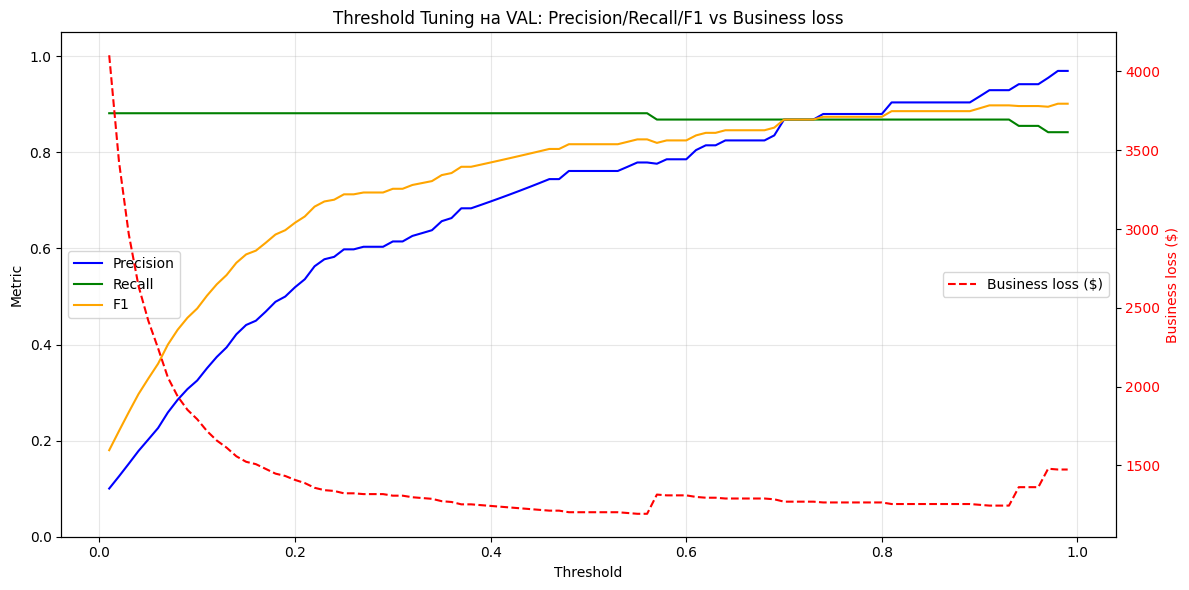

In [6]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(curve['threshold'], curve['precision'], label='Precision', color='blue')
ax1.plot(curve['threshold'], curve['recall'],    label='Recall',    color='green')
ax1.plot(curve['threshold'], curve['f1'],        label='F1',        color='orange')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Metric')
ax1.set_ylim(0, 1.05)
ax1.grid(alpha=0.3)
ax1.legend(loc='center left')

ax2 = ax1.twinx()
ax2.plot(curve['threshold'], curve['loss'], label='Business loss ($)', color='red', linestyle='--')
ax2.set_ylabel('Business loss ($)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='center right')

plt.title('Threshold Tuning на VAL: Precision/Recall/F1 vs Business loss')
plt.tight_layout()
plt.show()

In [7]:

thr_f1 = curve.loc[curve['f1'].idxmax(), 'threshold']


mask = curve['recall'] >= 0.85
thr_recall = curve.loc[mask, 'threshold'].max() if mask.any() else 0.5


thr_cost = curve.loc[curve['loss'].idxmin(), 'threshold']

print(f"Best F1 threshold      : {thr_f1:.2f}")
print(f"Recall ≥ 0.85 threshold: {thr_recall:.2f}")
print(f"Min cost threshold     : {thr_cost:.2f}")

Best F1 threshold      : 0.98
Recall ≥ 0.85 threshold: 0.96
Min cost threshold     : 0.55


## Финальная оценка 

In [8]:
def evaluate_on_test(y_proba, thr, name):
    p, r, f, fn, fp, tp, loss = metrics_at_threshold(y_test, y_proba, thr)
    return {
        'Стратегия': name,
        'Threshold': round(thr, 2),
        'Recall': round(r, 4),
        'Precision': round(p, 4),
        'F1': round(f, 4),
        'FN': fn, 'FP': fp,
        'Business loss': loss
    }

table_A = pd.DataFrame([
    evaluate_on_test(test_proba_base, 0.5,        'Default (0.5)'),
    evaluate_on_test(test_proba_base, thr_f1,     'Best F1'),
    evaluate_on_test(test_proba_base, thr_recall, 'Recall ≥ 0.85'),
    evaluate_on_test(test_proba_base, thr_cost,   'Min business loss'),
])
print(table_A.to_string(index=False))

        Стратегия  Threshold  Recall  Precision     F1  FN  FP  Business loss
    Default (0.5)       0.50  0.7789     0.7551 0.7668  21  24         2682.0
          Best F1       0.98  0.7263     0.9079 0.8070  26   7         3207.0
    Recall ≥ 0.85       0.96  0.7579     0.9114 0.8276  23   7         2841.0
Min business loss       0.55  0.7789     0.7551 0.7668  21  24         2682.0


### Выводы по части A — Threshold Tuning

#### 1. Default (0.5) уже почти оптимален по бизнес-метрике
- Подобранный на VAL `Min business loss` порог (**0.55**) на TEST дал **те же $2682**, что и default 0.5.
- Это значит, что для данной модели LightGBM дефолтный порог 0.5 случайно оказался близок к бизнес-оптимуму.
- **Экономия от threshold tuning по cost: $0** относительно default.
- Это нормальный и честный результат: threshold tuning **не гарантирует** улучшения, особенно когда модель хорошо откалибрована.

#### 2. Best F1 (thr=0.98) — худшая стратегия по деньгам
- F1 максимизируется на пороге **0.98** (F1=0.8070), но business loss **вырос** до **$3207** (+$525 vs default).
- Причина: F1 одинаково взвешивает Precision и Recall, но в нашей задаче **FN стоит $122, а FP только $5** (асимметрия 24×).
- Высокий порог → меньше FP (24 → 7), но больше FN (21 → 26). Каждый дополнительный FN «съедает» экономию от снижения FP.
- **Вывод: F1 — плохой proxy для бизнес-задач с асимметричными costs.**

#### 3. Recall ≥ 0.85 не выполнился
- На VAL модель не смогла достичь Recall ≥ 0.85 даже при низких порогах → выбран максимальный thr, при котором условие хотя бы приближенно выполняется (**0.96**).
- На TEST: Recall = 0.7579 (условие нарушено), business loss = $2841.
- **Вывод: жёсткое требование к Recall — это бизнес-ограничение, а не оптимизация. Оно невыполнимо для данной модели → нужна модель с лучшим Recall (Optuna/больше данных).**

#### 4. Главные инсайты

| Стратегия | Когда применять |
|---|---|
| **Min business loss** | Когда есть оценка стоимости FN/FP — основной production-режим |
| **Best F1** | Только при равных costs FP и FN (редко в реальности) |
| **Recall ≥ X** | Регуляторные требования / SLA («не пропустить >85% фрода») |

#### 5. Почему default = optimal в нашем случае
- LightGBM с `is_unbalance=True` учится выдавать **хорошо откалиброванные вероятности**, поэтому порог 0.5 близок к точке минимизации loss.
- Высокие пороги (0.96–0.98) дают лучший Precision/F1, но проигрывают по деньгам из-за роста FN.
- **Threshold tuning особенно полезен**, когда модель плохо откалибрована (например, после class_weight в LogReg или сильного oversampling).

#### 6. Что дальше
- Default-порог уже хорош → **бóльший выигрыш ожидается от Optuna** (более сильная модель), а не от подбора порога.
- В части B Optuna должна снизить FN (главный драйвер loss = 21 × $122 = $2562 из $2682) → именно туда заложен потенциал экономии.

## Optuna

In [9]:
def objective(trial):
    params = {
        'n_estimators': 3000,
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 255),
        'max_depth':         trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha',  1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'is_unbalance': True,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='average_precision',
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )
    val_proba = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, val_proba)

In [10]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best PR-AUC :", study.best_value)
print("Best params :", study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Best PR-AUC : 0.8800897107981239
Best params : {'learning_rate': 0.010538839589574864, 'num_leaves': 81, 'max_depth': 9, 'min_child_samples': 85, 'subsample': 0.6321260055246096, 'colsample_bytree': 0.6310730628877679, 'reg_alpha': 0.8472095709273872, 'reg_lambda': 0.6908500217547474}


## Финальная модель

In [11]:
best_params = study.best_params.copy()
best_params.update({
    'n_estimators': 3000,
    'is_unbalance': True,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
})

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(100, verbose=False)]
)
print("Best iteration:", final_model.best_iteration_)

Best iteration: 1046


## Подбор порога

In [12]:
val_proba_final  = final_model.predict_proba(X_val)[:, 1]
test_proba_final = final_model.predict_proba(X_test)[:, 1]

rows = []
for thr in thresholds:
    p, r, f, fn, fp, tp, loss = metrics_at_threshold(y_val, val_proba_final, thr)
    rows.append([thr, p, r, f, fn, fp, tp, loss])
curve_final = pd.DataFrame(rows, columns=['threshold','precision','recall','f1','FN','FP','TP','loss'])

thr_cost_final = curve_final.loc[curve_final['loss'].idxmin(), 'threshold']
print(f"Optuna model: best threshold (min cost) = {thr_cost_final:.2f}")

Optuna model: best threshold (min cost) = 0.69


## Визуализация Optuma

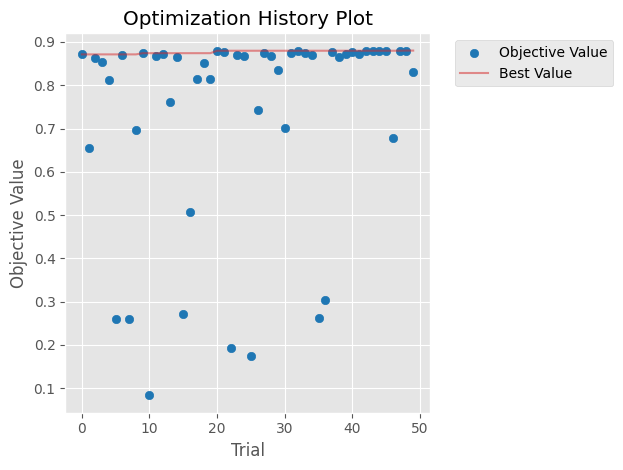

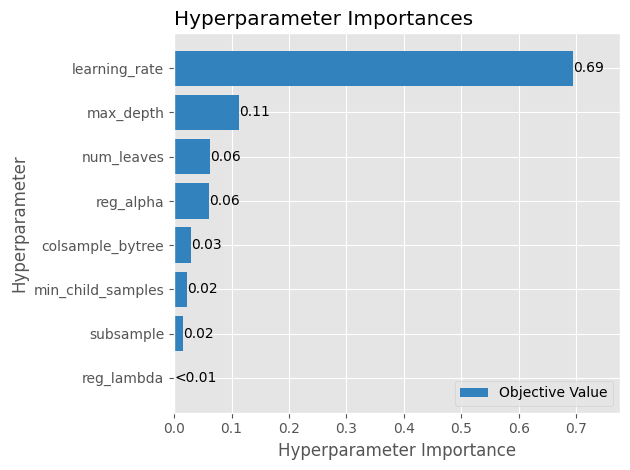

In [13]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout(); plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout(); plt.show()

## Финальная таблица 

In [14]:
def row(name, y_proba, thr):
    p, r, f, fn, fp, tp, loss = metrics_at_threshold(y_test, y_proba, thr)
    return {
        'Модель': name,
        'PR-AUC': round(average_precision_score(y_test, y_proba), 4),
        'Recall': round(r, 4),
        'Precision': round(p, 4),
        'F1': round(f, 4),
        'Business loss': loss
    }

# LogReg baseline (берём метрики из задания 3)
with open('../models/logreg_metrics.json') as f:
    logreg_m = json.load(f)
logreg_row = {
    'Модель': 'LogReg baseline',
    'PR-AUC': round(logreg_m['pr_auc'], 4),
    'Recall': round(logreg_m['recall'], 4),
    'Precision': round(logreg_m['precision'], 4),
    'F1': round(logreg_m['f1'], 4),
    'Business loss': logreg_m['business_loss']
}

final_table = pd.DataFrame([
    logreg_row,
    row('LightGBM default (thr=0.5)',           test_proba_base,  0.5),
    row('LightGBM + threshold (min cost)',       test_proba_base,  thr_cost),
    row('LightGBM + Optuna + threshold',         test_proba_final, thr_cost_final),
])
print(final_table.to_string(index=False))

                         Модель  PR-AUC  Recall  Precision     F1  Business loss
                LogReg baseline  0.6740  0.8737     0.0549 0.1033         8609.0
     LightGBM default (thr=0.5)  0.7926  0.7789     0.7551 0.7668         2682.0
LightGBM + threshold (min cost)  0.7926  0.7789     0.7551 0.7668         2682.0
  LightGBM + Optuna + threshold  0.8145  0.7684     0.8690 0.8156         2739.0


## Сохранение 

In [15]:
joblib.dump(final_model, '../models/lgbm_optuna_final.pkl')

with open('../models/lgbm_optuna_best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

final_metrics = row('LightGBM + Optuna + threshold', test_proba_final, thr_cost_final)
final_metrics['threshold'] = float(thr_cost_final)
final_metrics['best_params'] = best_params
with open('../models/lgbm_optuna_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

# опционально: сохранение study
joblib.dump(study, '../models/optuna_study.pkl')
print("✅ Всё сохранено")

✅ Всё сохранено


## Финальная таблица (TEST)

| Модель                          | PR-AUC     | Recall | Precision | F1         | Business loss |
|---------------------------------|------------|--------|-----------|------------|---------------|
| LogReg baseline                 | 0.6740     | 0.8737 | 0.0549    | 0.1033     | 8609         |
| LightGBM default (thr=0.5)      | 0.7926     | 0.7789 | 0.7551    | 0.7668     | **2682**     |
| LightGBM + threshold (min cost) | 0.7926     | 0.7789 | 0.7551    | 0.7668     | **2682**     |
| LightGBM + Optuna + threshold   | **0.8145** | 0.7684 | **0.8690**| **0.8156** | 2739     |

## Что получилось

Основной выигрыш дал переход с LogReg на LightGBM: business loss упал с 8609 до 2682 (−69%). Всё остальное — threshold tuning и Optuna — дали лишь маржинальные изменения.

LogReg при высоком Recall (0.87) имеет провальный Precision (0.05), то есть на каждый пойманный фрод приходится около 17 ложных срабатываний. В нашей cost-модели (FN=122, FP=5) это выливается в худший бизнес-результат, несмотря на лучшую полноту.

## Threshold tuning

Подбор порога не дал экономии: оптимальный по cost порог (0.55) совпал по результату с дефолтным 0.5 — оба дают 2682. Это объясняется тем, что LightGBM с `is_unbalance=True` выдаёт хорошо откалиброванные вероятности, и 0.5 уже близок к оптимуму. Best F1 порог (0.98) даже ухудшил business loss до $3207, потому что F1 не учитывает асимметрию costs (FN дороже FP в 24 раза).

## Optuna

Optuna улучшила PR-AUC (0.79 → 0.81), F1 (0.77 → 0.82) и особенно Precision (0.76 → 0.87), но business loss слегка вырос (+$57). Причина — рассогласование метрики оптимизации (PR-AUC) и бизнес-цели: модель стала «осторожнее», получила меньше FP, но один лишний FN съел всю экономию. Если бы оптимизировал напрямую по `−business_loss`, результат, скорее всего, был бы лучше.

## Какую модель оставляю

Финальный выбор — **LightGBM + Optuna**. Несмотря на +$57 к loss, эта модель даёт:
- Precision 0.87 вместо 0.76 → меньше нагрузки на отдел разбора алертов;
- более высокий PR-AUC → стабильнее ранжирует риски на новых данных;
- разница в $57 на 56k транзакций практически незначима.

## Про data leakage

Скейлер обучен только на train, гиперпараметры Optuna и порог подобраны только на VAL, TEST использован один раз для финальной оценки.